# Time and weighted representative periods

This notebook follows the temporal clustering work in energia. It demonstrates the current `Periods` hierarchy and `weight` metadata using a small synthetic dataset.

Representative selection below uses the standalone AHC port. Reduced-model integration remains a future step. No optimization solver is required.

Run with Python 3.12+ in an environment containing this energia checkout, NumPy, pandas, Matplotlib, and scikit-learn.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from energia import Model, Periods

from energia.surrogate.aggregation import ahc

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})


## 1. Build a time hierarchy

`Periods()` establishes a base duration. Its name supplies the interpretation: here we call it an hour. Multiplication creates a coarser period; assigning it to a model registers its name. The largest duration is the horizon.

In [2]:
m = Model()
m.h = Periods()
m.d = 24 * m.h
m.y = 365 * m.d

m.d / m.h  # 24
m.y / m.h  # 8760

8760

In [3]:
m.y.__dict__

{'size': 365,
 'weight': 1,
 'of': d,
 'isof': [],
 'label': '',
 'citations': '',
 'model': m,
 'name': 'y',
 'constraints': set(),
 'domains': [],
 'aspects': {},
 'slice': None,
 'n': None,
 'parent': None,
 'modes': [],
 '_howmany': {h: 8760}}

In [4]:
m = Model()
m.h = Periods()
m.d = 24 * m.h
nm_days = 365
m.y = nm_days * m.d

hierarchy = pd.DataFrame([
    {"name": p.name, "size": p.size,
     "basis": p.of.name if p.of is not None else None,
     "duration_in_hours": p.true_size, "weight": p.weight}
    for p in (m.h, m.d, m.y)
])
display(hierarchy)
print("Horizon:", m.horizon.name)
print("Hours per day:", m.d / m.h)
print("Hours per year:", m.y / m.h)
assert m.y / m.h == 8760


,name,size,basis,duration_in_hours,weight
0,h,1,None,1,1
1,d,24,h,24,1
2,y,365,d,8760,1


Horizon: y
Hours per day: 24
Hours per year: 8760


## 2. Give representative hours names and weights

A representative hour has the same duration as the original hour. Its weight records how many original hours it represents. We use a separate model for this metadata example; these objects do not yet form an automatically reduced optimization time index.

Positive multiplication continues to create duration relationships. It creates a new `Periods` with the default weight of 1; it does not propagate a representative's weight.

In [5]:
representatives = Model()
representatives.h = Periods()
representatives.h_ahc_0 = Periods(of=representatives.h, weight=4)
representatives.h_ahc_1 = Periods(of=representatives.h, weight=4)

weighted_periods = [representatives.h_ahc_0, representatives.h_ahc_1]
display(pd.DataFrame([
    {"name": p.name, "duration_in_hours": p.true_size, "weight": p.weight,
     "represented_hours": p.true_size * p.weight}
    for p in weighted_periods
]))
assert all(p.true_size == representatives.h.true_size for p in weighted_periods)
assert representatives.h.weight == 1


,name,duration_in_hours,weight,represented_hours
0,h_ahc_0,1,4,4
1,h_ahc_1,1,4,4


## 4. Run AHC and inspect the representative mapping

Cluster the aligned series into two contiguous groups using standardized features and Ward linkage. The actual hour nearest each cluster centroid represents that group; ties select the earliest hour. The same mapping applies to both features.

Create named `Periods` from the resulting occurrence weights. Model integration is still separate from this metadata demonstration.
`legacy` is the default. This first example explicitly uses `nearest_centroid`; both choices are compared below.


In [7]:
result = ahc(data["demand_MW"].to_numpy(), data["availability"].to_numpy(), periods=2, selection="nearest_centroid")
labels = result.labels
selected_hours = result.representative_indices
weights = result.weights

clustered = Model()
clustered.h = Periods()
weighted_periods = []
for i, weight in enumerate(weights):
    period = Periods(of=clustered.h, weight=int(weight))
    setattr(clustered, f"h_ahc_{i}", period)
    weighted_periods.append(period)

mapping = pd.DataFrame({
    "original_hour": data.index,
    "representative": [weighted_periods[i].name for i in labels],
    "selected_original_hour": selected_hours[labels],
})
reduced = data.iloc[selected_hours].copy()
reduced.index = pd.Index([p.name for p in weighted_periods], name="representative")
reduced["weight"] = weights

display(mapping)
display(reduced)
print("Standardized centroid SSE:", result.inertia)
print("Standardized representative SSE:", result.reconstruction_error)
assert weights.sum() == len(data)
assert all(labels[hour] == cluster for cluster, hour in enumerate(selected_hours))


,original_hour,representative,selected_original_hour
0,0,h_ahc_0,1
1,1,h_ahc_0,1
2,2,h_ahc_0,1
3,3,h_ahc_0,1
4,4,h_ahc_1,5
5,5,h_ahc_1,5
6,6,h_ahc_1,5
7,7,h_ahc_1,5


,demand_MW,availability,weight
representative,,,
h_ahc_0,11,0.3,4
h_ahc_1,21,0.7,4


Standardized centroid SSE: 1.0457516339869284
Standardized representative SSE: 1.0457516339869284


## 5. Reconstruct and check totals

Expand the selected samples through the mapping to inspect approximation error. Apply weights explicitly when computing the represented demand energy. `Periods.weight` currently stores metadata; it does not automatically change model sums, objectives, or constraints.

This intentionally simple dataset preserves total demand energy exactly even though individual samples differ. That is not a general guarantee of clustering.

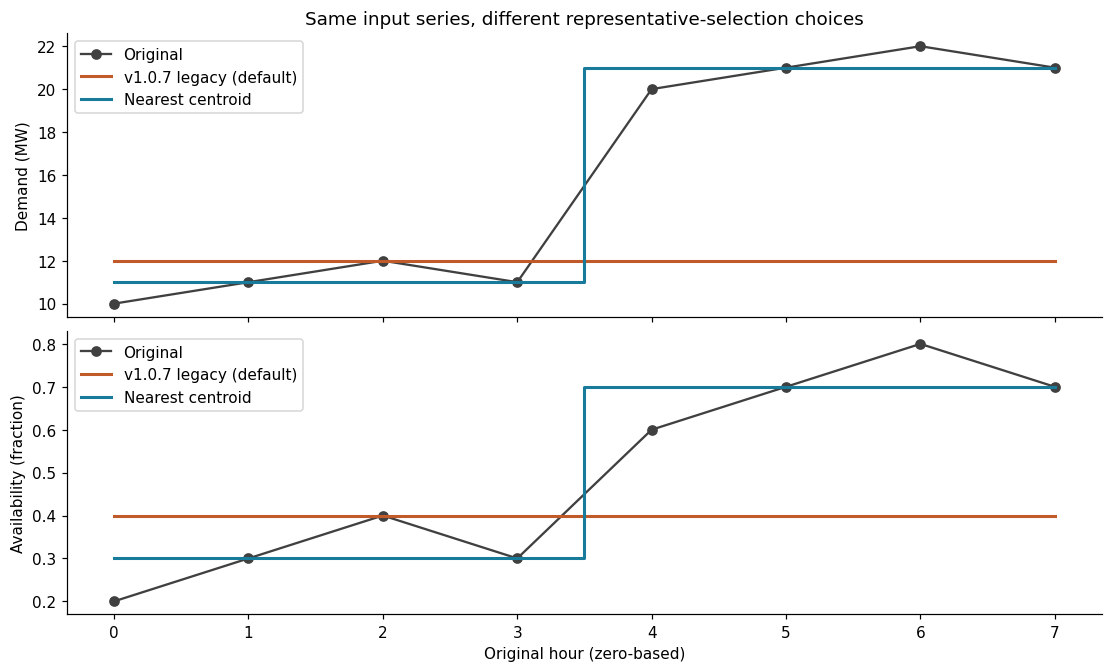

,selection,selected_hours,centroid_SSE,representative_SSE,weighted_demand_MWh
0,v1.0.7 legacy (default),"[2, 2]",1.045752,22.797386,96.0
1,Nearest centroid,"[1, 5]",1.045752,1.045752,128.0


In [10]:
legacy = ahc(data["demand_MW"].to_numpy(), data["availability"].to_numpy(), periods=2)
assert legacy.selection == "legacy"
policies = {"v1.0.7 legacy (default)": legacy, "Nearest centroid": result}
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)
for ax, column in zip(axes, data.columns):
    ax.plot(data.index, data[column], "o-", color="0.25", label="Original", linewidth=1.5)
    for (name, selected), color in zip(policies.items(), ["#c05a28", "#187b9b"]):
        values = selected.reconstruct()[:, data.columns.get_loc(column)]
        ax.step(data.index, values, where="mid", label=name, color=color, linewidth=2)
    ax.set_ylabel("Demand (MW)" if column == "demand_MW" else "Availability (fraction)")
    ax.legend(loc="best")
axes[0].set_title("Same input series, different representative-selection choices")
axes[-1].set_xlabel("Original hour (zero-based)")
plt.show()
display(pd.DataFrame([
    {"selection": name, "selected_hours": selected.representative_indices.tolist(),
     "centroid_SSE": selected.inertia, "representative_SSE": selected.reconstruction_error,
     "weighted_demand_MWh": selected.reconstruct()[:, 0].sum()}
    for name, selected in policies.items()
]))


## 7. Historical-data comparison: v1.0.7 versus the new selection method

**Legacy means Energia v1.0.7**, pinned to commit `0604a26ee45a564bcd83c736077944cb1c59a50d`. The current `selection="legacy"` option reproduced that historical function's representative indices, weights, and selected profiles in all ten comparisons. It remains the default; `selection="nearest_centroid"` is optional.

These plots read saved results from `docs/validation/ahc/results.json`; they do not rerun the historical datasets. Each case uses 365 days of hourly inputs, reduced to 20 or 35 representative days. Both algorithms ran with the same installed dependencies, not recreated v1.0.7-era environments. The source version is v1.0.7 even though its AHC source also matches the inspected September 2023 revision.

Reconstruction errors below use the **same corrected standardized representative SSE** for both selections. The legacy bar evaluates the v1.0.7-selected profiles using that common metric; it is **not** v1.0.7's reported `wcss_sum`. Compare policies within each dataset because different datasets have different features.


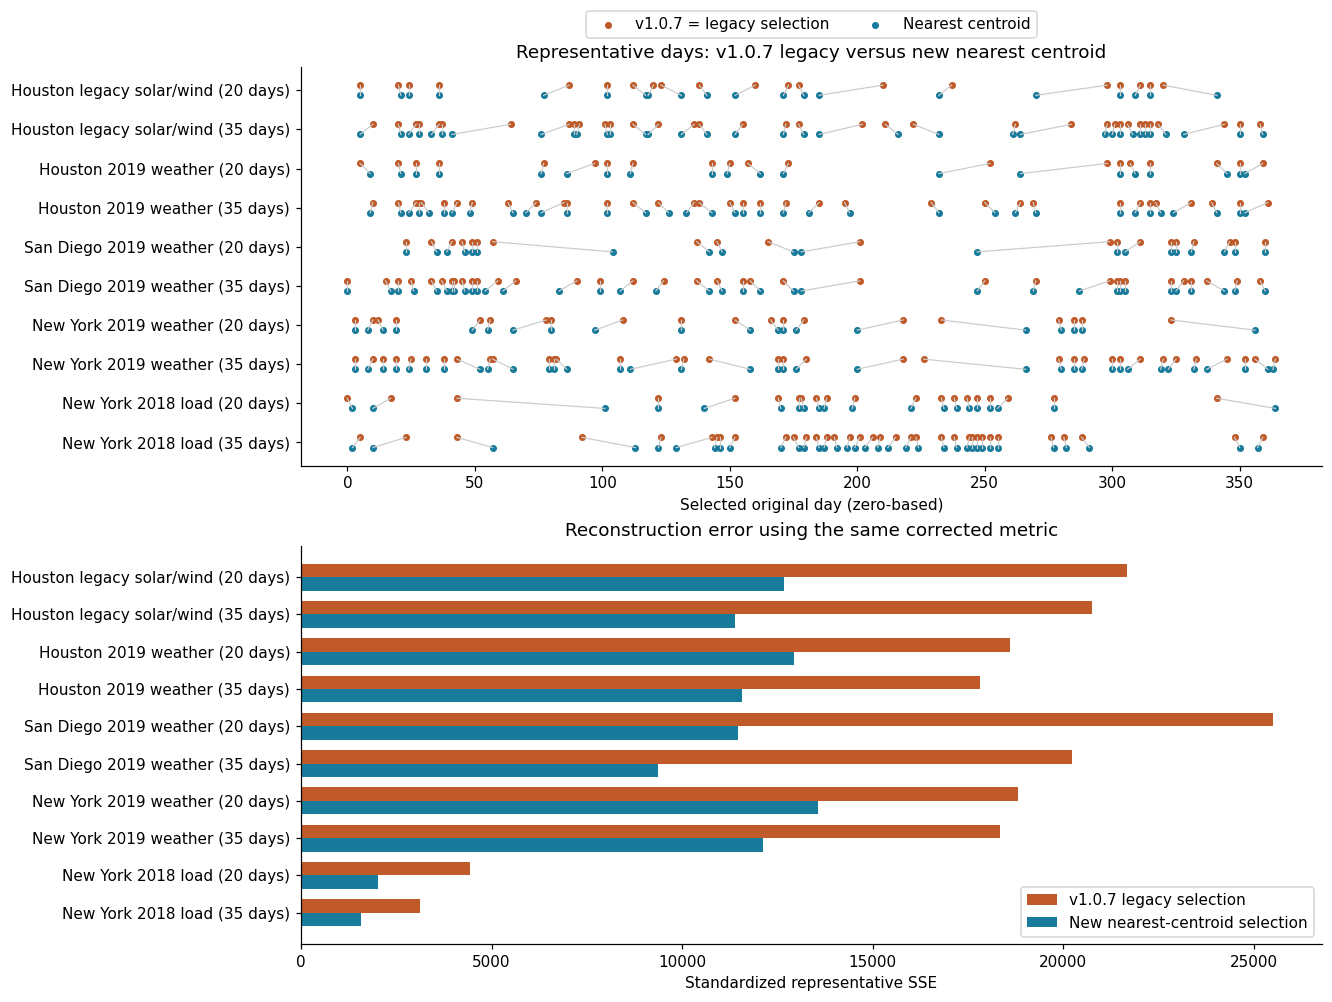

In [13]:
import json
from pathlib import Path

comparison_candidates = [Path("../validation/ahc/results.json"), Path("docs/validation/ahc/results.json")]
comparison_path = next((path for path in comparison_candidates if path.is_file()), None)
if comparison_path is None:
    raise FileNotFoundError("Run from docs/examples or the repository root to find docs/validation/ahc/results.json")
comparison = json.loads(comparison_path.read_text())
cases = comparison["results"]
case_names = {
    "houston_legacy_solar_wind": "Houston legacy solar/wind",
    "houston_2019": "Houston 2019 weather",
    "sandiego_2019": "San Diego 2019 weather",
    "newyork_2019_weather": "New York 2019 weather",
    "newyork_2018_load": "New York 2018 load",
}
fig, axes = plt.subplots(2, 1, figsize=(12, 9), constrained_layout=True)
for row, case in enumerate(cases):
    historical = np.array(case["legacy_representatives"])
    compatible = np.array(case["legacy_mode_representatives"])
    nearest = np.array(case["nearest_centroid_representatives"])
    assert np.array_equal(historical, compatible)
    for old_day, new_day in zip(compatible, nearest):
        axes[0].plot([old_day, new_day], [row - 0.13, row + 0.13], color="0.8", linewidth=0.8)
    axes[0].scatter(compatible, np.full(len(compatible), row - 0.13), color="#c05a28", s=13,
                    label="v1.0.7 = legacy selection" if row == 0 else None)
    axes[0].scatter(nearest, np.full(len(nearest), row + 0.13), color="#187b9b", s=13,
                    label="Nearest centroid" if row == 0 else None)
case_labels = [f"{case_names[c['dataset']]} ({c['clusters']} days)" for c in cases]
axes[0].set(yticks=range(len(cases)), yticklabels=case_labels, xlabel="Selected original day (zero-based)",
            title="Representative days: v1.0.7 legacy versus new nearest centroid")
axes[0].invert_yaxis()
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.16), ncol=2)
positions = np.arange(len(cases))
axes[1].barh(positions - 0.18, [c["legacy_mode_reconstruction_error"] for c in cases], height=0.36,
             color="#c05a28", label="v1.0.7 legacy selection")
axes[1].barh(positions + 0.18, [c["nearest_centroid_reconstruction_error"] for c in cases], height=0.36,
             color="#187b9b", label="New nearest-centroid selection")
axes[1].set(yticks=positions, yticklabels=case_labels, xlabel="Standardized representative SSE",
            title="Reconstruction error using the same corrected metric")
axes[1].invert_yaxis()
axes[1].legend()
plt.show()


### Effect of the selection change and the separate error-reporting fix

The following comparison holds inputs, standardization, and the tested cluster memberships fixed. It evaluates each method's selected profiles against every original member of their clusters. Percentage reduction is `100 × (legacy SSE − new SSE) / legacy SSE`.

Why reconstruction error decreases:

1. **Correct centroid association.** In v1.0.7, centroid rows are returned in sorted cluster-label order, but then labeled using first-occurrence order. This can associate a cluster with a different cluster's centroid. The new method computes each cluster's own centroid directly.
2. **Representative search within the cluster.** The new method chooses the closest observed member of that cluster. The historical lookup searches the entire distance column for a matching minimum, so equal distances can select a point outside the cluster or repeat a representative. That behavior is demonstrated by the small regression fixture; it has not been separately established as the cause of every historical-data difference.
3. **Why nearest-centroid selection helps.** For a fixed cluster, summed squared distance to a candidate representative equals the cluster's centroid SSE plus its size times the candidate's squared distance to the centroid. Selecting the nearest member therefore minimizes reconstruction SSE among the cluster's observed members, up to the documented numerical-tie tolerance. Earliest-period tie breaking makes ties deterministic; it is not the source of the large reductions shown here.

**Error reporting is a separate fix.** Both current options use actual centroids and accumulate errors across all parent groups. Historical `wcss_sum` divided its distance sum by the cluster count and retained only the final parent's sum. Correcting that reporting does not itself improve selected profiles. The ten historical comparisons have one parent each; multiple-parent accumulation is covered by the behavioral tests.

These results concern standardized input reconstruction. They do not establish better annual totals, demand peaks, storage trajectories, costs, or optimization decisions. Cluster contiguity and chronological ordering are retained separately from the representative-selection rule.


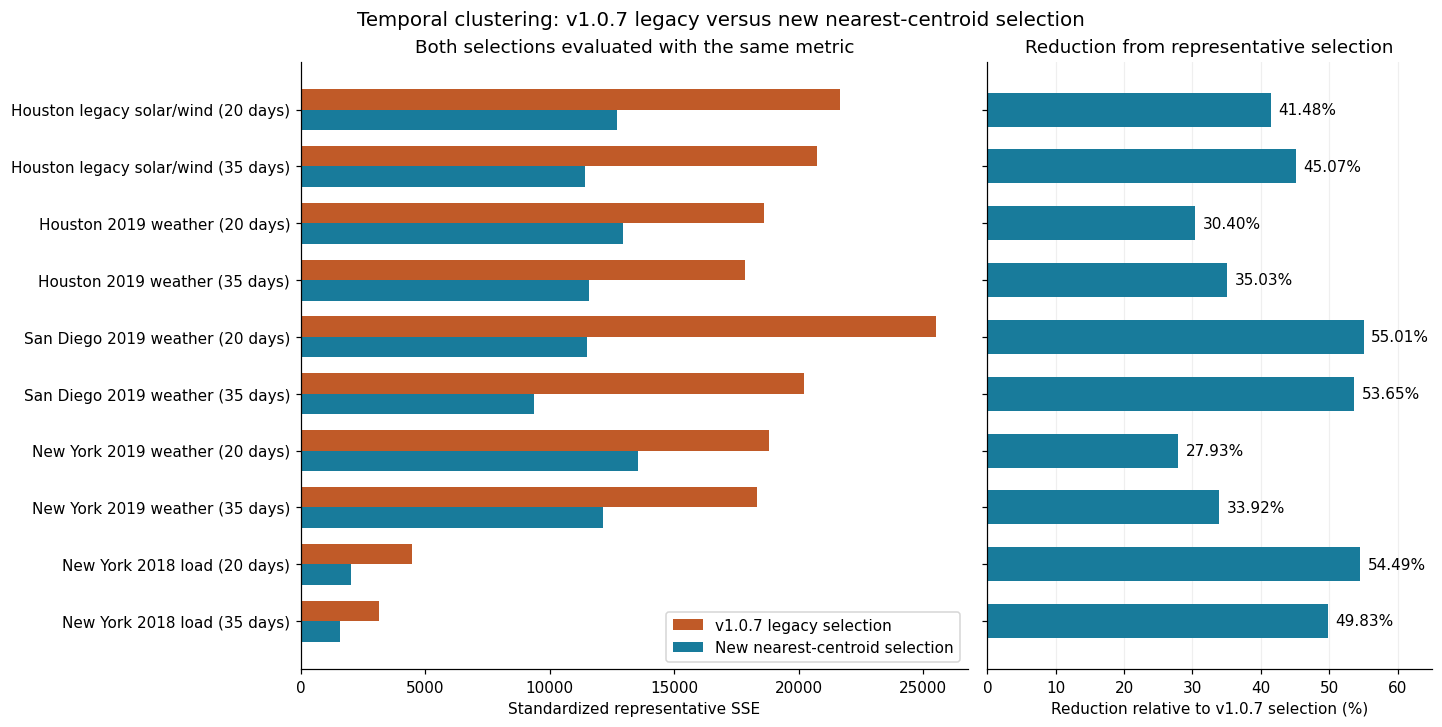

,dataset,representative_days,v1_0_7_selection_SSE,new_selection_SSE,SSE_reduction_percent
0,Houston legacy solar/wind,20,21663.837761,12678.719570,41.475191
1,Houston legacy solar/wind,35,20742.461027,11393.594559,45.071154
2,Houston 2019 weather,20,18605.058451,12948.210215,30.404894
3,Houston 2019 weather,35,17828.506845,11582.609784,35.033203
4,San Diego 2019 weather,20,25509.022477,11475.398926,55.014353
5,San Diego 2019 weather,35,20228.065751,9375.384340,53.651602
6,New York 2019 weather,20,18814.414107,13559.252177,27.931574
7,New York 2019 weather,35,18340.504498,12119.091001,33.921714
8,New York 2018 load,20,4444.410017,2022.662226,54.489747
9,New York 2018 load,35,3116.786407,1563.681340,49.830334


Reconstruction SSE reduction across the ten cases: 27.93% to 55.01%.


In [14]:
fix_comparison = pd.DataFrame([
    {"dataset": case_names[c["dataset"]], "representative_days": c["clusters"],
     "v1_0_7_selection_SSE": c["legacy_mode_reconstruction_error"],
     "new_selection_SSE": c["nearest_centroid_reconstruction_error"]}
    for c in cases
])
fix_comparison["SSE_reduction_percent"] = 100 * (
    fix_comparison["v1_0_7_selection_SSE"] - fix_comparison["new_selection_SSE"]
) / fix_comparison["v1_0_7_selection_SSE"]
assert (fix_comparison["SSE_reduction_percent"] >= -1e-10).all()

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True, constrained_layout=True,
                         gridspec_kw={"width_ratios": [1.5, 1]})
y = np.arange(len(fix_comparison))
axes[0].barh(y - 0.18, fix_comparison["v1_0_7_selection_SSE"], height=0.36,
             color="#c05a28", label="v1.0.7 legacy selection")
axes[0].barh(y + 0.18, fix_comparison["new_selection_SSE"], height=0.36,
             color="#187b9b", label="New nearest-centroid selection")
axes[0].set(yticks=y, yticklabels=case_labels, xlabel="Standardized representative SSE",
            title="Both selections evaluated with the same metric")
axes[0].invert_yaxis()
axes[0].legend(loc="lower right")
bars = axes[1].barh(y, fix_comparison["SSE_reduction_percent"], color="#187b9b", height=0.6)
axes[1].bar_label(bars, fmt="%.2f%%", padding=5)
axes[1].set(xlabel="Reduction relative to v1.0.7 selection (%)", xlim=(0, 65),
            title="Reduction from representative selection")
axes[1].grid(axis="x", alpha=0.2)
axes[1].set_axisbelow(True)
fig.suptitle("Temporal clustering: v1.0.7 legacy versus new nearest-centroid selection", fontsize=13)

plot_dir = comparison_path.resolve().parents[2] / "examples" / "plots"
plot_dir.mkdir(exist_ok=True)
fig.savefig(plot_dir / "temporal_clustering_selection_comparison.png", dpi=180, bbox_inches="tight")
fig.savefig(plot_dir / "temporal_clustering_selection_comparison.svg", bbox_inches="tight")
plt.show()
display(fix_comparison.style.format({
    "v1_0_7_selection_SSE": "{:.6f}", "new_selection_SSE": "{:.6f}",
    "SSE_reduction_percent": "{:.6f}",
}))
print(f"Reconstruction SSE reduction across the ten cases: "
      f"{fix_comparison.SSE_reduction_percent.min():.2f}% to "
      f"{fix_comparison.SSE_reduction_percent.max():.2f}%.")


## Next: reduced-model integration

The AHC function now supplies representative profiles, mappings, weights, and error measures. Connecting these to model indices, weighted sums, and storage continuity remains separate work. The proposed dictionary-based period relationships are not implemented here.